# Nodal Markets on the WSCC 9-Bus Network — Fundamentals

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

This is the first notebook in the illustrative series. It builds the WSCC / IEEE
9-bus test case, clears a single nodal energy market on it, and reads off the
pieces every later notebook reuses: **locational marginal prices (LMPs)**,
**congestion rent**, **transport (net-interchange) constraints and transfer
rent**, and **self-schedules**. It closes with the three settlement **ledgers**
and a **sandbox** for dialling scenarios and watching the revenue flows respond.

It poses no market *issue* of its own — the seam and congestion-revenue-allocation
issues live in the 200- and 300-series notebooks. Everything here runs on the
shared teaching libraries (`wscc9_model`, `footprints`, `revenue_allocation`,
`wscc9_figures`) built on the `seams_engine` PTDF DC-OPF and the `nodal_plot`
figures.

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py", "wscc9_figures.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

# Clean tables on PDF export: give DataFrames/Series a booktabs LaTeX rendering.
# Jupyter and Colab still show the normal HTML tables; `nbconvert --to pdf` picks
# up this text/latex representation, so tables come out as real ruled tables.
def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

### Generation & load table

The 9-bus system has three generators and three
loads. 

```
        (1)gen $50            (3)gen $20
          |                     |
         [4]---[5]load--------[6]---[7]load
          |                     |
         [9]load---[8]---------/
                    |
                  (2)gen $35
```
Lines (rating MW): `0:1-4(250) 1:4-5(250) 2:5-6(150) 3:3-6(300) 4:6-7(150) 5:7-8(250) 6:8-2(250) 7:8-9(250) 8:9-4(250)`

In [3]:
# The teaching fleet and loads live in wscc9_model (edit there to change the
# baseline, or override the dicts here). Bus 3 is the CHEAPEST unit ($20), bus 1
# the most expensive ($50) — a price gradient that makes congestion bite.
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}

print('loads (MW):', LOADS)
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. Shared network & shift factors

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

Each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ is built.

In [4]:
pt = shift_factors()   # DC shift-factor matrix (PTDF) of the base network
print('Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)')
sf_table(pt)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)

,bus 1,bus 2,bus 3,bus 4,bus 5,bus 6,bus 7,bus 8,bus 9
line_0 (1-4),0.0,-1.000,-1.000,-1.0,-1.000,-1.000,-1.000,-1.000,-1.000
line_1 (4-5),0.0,-0.361,-0.615,-0.0,-0.865,-0.615,-0.467,-0.361,-0.125
line_2 (5-6),0.0,-0.361,-0.615,-0.0,0.135,-0.615,-0.467,-0.361,-0.125
line_3 (3-6),0.0,0.000,1.000,-0.0,0.000,0.000,-0.000,0.000,0.000
line_4 (6-7),0.0,-0.361,0.385,0.0,0.135,0.385,-0.467,-0.361,-0.125
line_5 (7-8),0.0,-0.361,0.385,-0.0,0.135,0.385,0.533,-0.361,-0.125
line_6 (8-2),0.0,-1.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000
line_7 (8-9),0.0,0.639,0.385,0.0,0.135,0.385,0.533,0.639,-0.125
line_8 (9-4),0.0,0.639,0.385,0.0,0.135,0.385,0.533,0.639,0.875


### Line admittance map

The WSCC 9-bus assigns a distinct reactance $x_m$ to every line. For DC flow the
power a line carries per unit of angle difference across its **susceptance**
$b_m = 1/x_m$. The cell below draws each line with a width
proportional to $b_m$ (wider = lower $x$ = more admittance), giving a physical
picture of where power prefers to flow before any dispatch is chosen. 

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


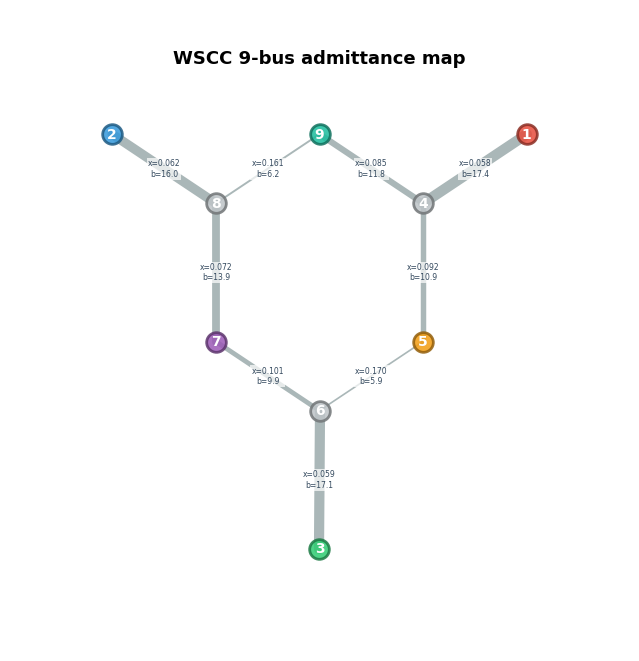

,x (reactance),b = 1/x,draw width
line_0 (1-4),0.0576,17.36,7.50
line_3 (3-6),0.0586,17.06,7.34
line_6 (8-2),0.0625,16.00,6.75
line_5 (7-8),0.0720,13.89,5.59
line_8 (9-4),0.0850,11.76,4.43
line_1 (4-5),0.0920,10.87,3.94
line_4 (6-7),0.1008,9.92,3.42
line_7 (8-9),0.1610,6.21,1.38
line_2 (5-6),0.1700,5.88,1.20


In [5]:
pt = compute_ptdf(build_network(), slack_bus='1')
widths = susceptance_widths(pt, wmin=1.2, wmax=7.5)   # {line: linewidth} from b = 1/x

# Colour the nodes with the SAME per-bus palette used throughout the notebook:
# gen/load buses take their palette colour, pure transit buses stay grey. The
# membership comes from the fleet (not the dispatch), so these node colours match
# the dispatched figures exactly -- this is purely a susceptance map, no flows.
node_colors = BUS_COLORS   # canonical per-bus palette (defined with pt above)

# Pure susceptance map: no dispatch annotations, no flows -- width encodes
# admittance only, nodes carry the standard palette colour.
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=node_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines},   # 0 flow -> no arrows, grey lines
    line_widths=widths,
    title='WSCC 9-bus admittance map', #  (wider = lower reactance = carries more flow per unit angle)
)
# annotate each line with its x and b
for l, (b0, b1) in zip(pt.lines, pt.line_buses):
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    b = pt.susceptance[pt.line_idx[l]]
    ax.text(xm, ym, f'x={1/b:.3f}\nb={b:.1f}', fontsize=5.5, ha='center', va='center',
            color='#34495E', bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.8), zorder=6)
plt.show()

pd.DataFrame({
    'x (reactance)': [round(1 / pt.susceptance[pt.line_idx[l]], 4) for l in pt.lines],
    'b = 1/x': [round(pt.susceptance[pt.line_idx[l]], 2) for l in pt.lines],
    'draw width': [round(widths[l], 2) for l in pt.lines],
}, index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)]).sort_values('b = 1/x', ascending=False)

## 2. Market engine and nodal dispatch

### The dispatch each engine solves, its Lagrangian, and the bus prices

`solve_engine_dispatch` clears **one engine's** DC-OPF on the shared network: a
bid-based security-constrained economic dispatch (SCED) reduced to a **single
period with energy-cost bids only** (no unit commitment) and a **single
system-wide energy balance**. An engine $M$ brings its resources $\mathcal R^M$
(cost $c_i$, cap $\bar g_i$ at bus $\mathrm{bus}(i)$), its served load $d^M_n$, an
activated line set $\mathcal M^M_{\mathrm{act}}$, and any **exogenous** cross-footprint
schedule $\mathrm{exo}^M_n$ (zero for a stand-alone clear).

**Nomenclature.** Sets are script capitals; an element is the matching
lower-case letter (upper-case for markets).

| Symbol | Code | Definition |
|---|---|---|
| $\mathcal N$ | `pt.buses` | the set of buses in the network; $n\in\mathcal N$ |
| $\mathcal M$ | `pt.lines` | the set of monitored lines (network constraints); $m\in\mathcal M$ |
| $\mathcal E$ | `make_engine` | the set of market engines operating on the shared network; $M\in\mathcal E$ |
| $\mathcal R^M$ | `eng.gens` | the set of resources (generators) cleared by market $M$; $i\in\mathcal R^M$ |
| $\mathcal M^M_{\mathrm{act}}\subseteq\mathcal M$ | `eng.activated_lines` | the lines whose limits market $M$ activates (enforces) in its clearing |
| $c_i,\ \bar g_i,\ \mathrm{bus}(i)$ | `gens[i]['cost'/'p_nom'/'bus']` | marginal cost, capacity, and host bus of resource $i$ |
| $g_i$ | `res.dispatch` | dispatch of resource $i$ — the engine's decision variable, $0\le g_i\le\bar g_i$ |
| $d^M_n$ | `eng.loads` | load served by market $M$ at bus $n$ (zero wherever $M$ serves no load) |
| $SF_{n,m}$ | `pt` (`shift_factors`) | shift factor of bus $n$ on line $m$ |
| $\bar F_m$ | `LINE_RATINGS` | operating limit of line $m$ |
| $\mathrm{exo}^M_n$ | `exo=` | exogenous scheduled injection at bus $n$ in market $M$'s clear (fixed before it runs) |
| $u_n$ | `res.shed_by_bus` | unserved (shed) load at bus $n$ — the relaxation variable, $0\le u_n\le d^M_n$ (zero unless the relaxation is enabled) |
| $V$ | `SHED_PRICE` | load-shed penalty price, \$/MWh (the engine's `shed_price`) |

Case carries meaning here: lower-case $m$ indexes a **line**, upper-case $M$
names a **market engine** drawn from $\mathcal E$, and script $\mathcal M$ is
the set of lines — three different objects. The formulation is written for a
general $M\in\mathcal E$; the unified clearing of this section is the special
case where $\mathcal E$ has a single member spanning every bus.


**Objective — minimise the engine's own dispatch cost.**

$$\min_{0\le g_i\le \bar g_i}\ \ C^M=\sum_{i\in\mathcal R^M} c_i\,g_i. \qquad\qquad(1)$$

*In words.* Stack up the engine's own generators cheapest-first to cover its obligation
(no-load, start-up and shut-down terms drop out in this single-period, energy-only cut).

**Energy balance — its dual is the energy price $\lambda^M$.**

$$\sum_{i\in\mathcal R^M} g_i=\sum_{n\in\mathcal N} d^M_n-\sum_{n\in\mathcal N} \mathrm{exo}^M_n,\   \ [\lambda^M]\qquad\qquad(2)\quad$$

*In words.* The engine's generation serves its own load net of any scheduled interchange:
$\mathrm{exo}^M_n>0$ is power injected into the footprint (an import), $\mathrm{exo}^M_n<0$ a
withdrawal (an export). $\lambda^M$ is the single system-wide energy price (`res.energy_price`). Note the
**market scoping sits on the data, not the bus set**: the sums run over every bus
$n\in\mathcal N$, but $d^M_n$ vanishes wherever $M$ serves no load, and $\mathrm{exo}^M_n$
may sit at *any* bus of the shared network.

**Feasibility relaxation — load shedding at a penalty.** Constraint (2) can be
impossible to satisfy — load behind a binding line with too little reachable
generation — and a market clearing must not simply fail. The engine therefore
carries an **opt-in power-balance relaxation** (`shed_price`; the `# -- EDIT --`
cell below sets `SHED_PRICE = 150` \$/MWh): every load bus gains an
unserved-load variable $u_n$, penalised in the objective and netted from the
load it relaxes,

$$\min\ \sum_{i\in\mathcal R^M} c_i\,g_i+V\!\sum_{n\in\mathcal N} u_n,\qquad
  \sum_{i\in\mathcal R^M} g_i=\sum_{n\in\mathcal N}\big(d^M_n-u_n\big)-\sum_{n\in\mathcal N}\mathrm{exo}^M_n,\qquad
  0\le u_n\le d^M_n,$$

with every flow built from the **served** load $d^M_n-u_n$. Mechanically $u_n$
is a virtual generator at the load bus with cost $V$: nothing sheds while
cheaper supply can still reach the bus, and wherever shedding is interior the
bus price is exactly $\lambda^M_n=V$ — the relaxation penalty doubles as the
price cap. (EDAM relaxes each BAA's power balance the same way: energy
supply-shortfall variables priced at penalty costs in the objective.) The
equations below are written without $u_n$; in every worked example the
relaxation is enabled but slack ($u_n=0$ throughout).

**Flow and activated limits — duals $\mu^M_m$.**

$$F^M_m=\sum_{n\in\mathcal N} SF_{n,m}\,p^{\mathrm{inj},M}_n\ \ (m\in\mathcal M),\qquad
  -\bar F_m\le F^M_m\le \bar F_m\ \ [\mu^M_m]\ \ (m\in\mathcal M^M_{\mathrm{act}}),\qquad
  p^{\mathrm{inj},M}_n=\!\!\!\sum_{i\in\mathcal R^M:\,\mathrm{bus}(i)=n}\!\!\!g_i-d^M_n+\mathrm{exo}^M_n\ \ (n\in\mathcal N). \qquad(3)$$

*In words.* The engine's flow on a line is the shift-factor-weighted sum of **its own** net
injections, held within the rating **only on the lines it activates**. A line outside
$\mathcal M^M_{\mathrm{act}}$ has its limit relaxed and stays silent (`activated_lines`).

**The Lagrangian.**

$$\mathcal L^M(g,\lambda^M,\mu^M,\underline\mu^M,\overline\mu^M)=\sum_{i\in\mathcal R^M} c_i\,g_i-\lambda^M\!\Big(\sum_{i\in\mathcal R^M} g_i-\sum_{n\in\mathcal N} d^M_n+\sum_{n\in\mathcal N}\mathrm{exo}^M_n\Big)-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!\mu^M_m\,F^M_m+\sum_{i\in\mathcal R^M}\overline\mu^M_i\,(g_i-\bar g_i)-\sum_{i\in\mathcal R^M}\underline\mu^M_i\,g_i. \qquad(4)$$

*In words.* Cost, minus the energy-balance multiplier times the imbalance, minus each activated
line's (signed) congestion multiplier times the flow on it, plus one multiplier per generator
capacity limit: $\overline\mu^M_i\ge 0$ on the upper limit $g_i\le\bar g_i$ and
$\underline\mu^M_i\ge 0$ on the lower limit $g_i\ge 0$. $\lambda^M$ and the $\mu^M_m$ are exactly
`res.energy_price` and `res.line_dual`.

**Complementary slackness.** Each capacity multiplier is non-zero only when its own limit binds:

$$\overline\mu^M_i\,(g_i-\bar g_i)=0,\qquad \underline\mu^M_i\,g_i=0,\qquad \overline\mu^M_i,\underline\mu^M_i\ge 0,\qquad \forall\,i\in\mathcal R^M.$$

A fully-loaded unit ($g_i=\bar g_i$) may carry $\overline\mu^M_i>0$, an idle unit ($g_i=0$) may
carry $\underline\mu^M_i>0$, and a **marginal** unit ($0<g_i<\bar g_i$) has both equal to zero.

**Stationarity — where the price comes from.** At the optimum the Lagrangian is stationary in
each dispatch variable. For a generator $i$ at bus $n=\mathrm{bus}(i)$, using $\partial F^M_m/\partial g_i=SF_{n,m}$:

$$\frac{\partial \mathcal L^M}{\partial g_i}
  = c_i-\lambda^M-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^M_m\;+\;\overline\mu^M_i-\underline\mu^M_i\;=\;0 .$$

For a **marginal** unit the two bound multipliers vanish by complementary slackness, so the
$\overline\mu^M_i-\underline\mu^M_i$ term drops and we are left with
$c_i=\lambda^M+\sum_{m}SF_{n,m}\,\mu^M_m$.

**Nodal LMP — the price at every bus.**

$$\lambda^M_n=\lambda^M+\sum_{m\in\mathcal M^M_{\mathrm{act}}}SF_{n,m}\,\mu^M_m\ \ (n\in\mathcal N). \qquad\qquad(5)$$

*In words.* A bus's price is the system energy price plus, for every binding activated line, that
line's shadow price scaled by the bus's shift factor onto it. With nothing binding, every bus
collapses to the one price $\lambda^M$. **Section 2 runs the unified counterfactual**: a single
engine over **all** buses with $\mathrm{exo}=0$ and every limit enforced — the single-price
benchmark the rest of the notebook builds on.

### Congestion rent

Unified clearing is the single engine over **all** buses ($\mathrm{exo}=0$, every
line activated), so we drop the engine superscript: write $\lambda_n\equiv\lambda^M_n$,
$\mu_m\equiv\mu^M_m$, $d_n\equiv d^M_n$, and $\mathcal M_{\mathrm{act}}$ for the activated set; let
$g_n=\sum_{i:\,\mathrm{bus}(i)=n} g_i$ be the dispatch at bus $n$. Value each binding
line's limit at its shadow price — equivalently, net the bus-level payments:

$$R=\sum_{m\in\mathcal M_{\mathrm{act}}}|\mu_m|\,|F_m|
   =\underbrace{\sum_{n\in\mathcal N}\lambda_n d_n}_{\text{paid by load}}
   -\underbrace{\sum_{n\in\mathcal N}\lambda_n g_n}_{\text{paid to generation}}. \qquad (6)$$

*In words.* The congestion rent (merchandising surplus) is the shadow price of each binding
line times the power on it — and it equals exactly what load pays minus what generation is
paid, because the energy components net to zero (total generation $=$ total load). **No
binding line $\Rightarrow$ no price separation $\Rightarrow R=0$.** 

**Edit below:** generator costs, load levels, and line ratings. Limiting a line rating may
create congestion and price separation on the constrained
path.

In [6]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0, 'line_1': 30.0, 'line_2': 30.0}   # adjust line_4 (6-7, internal to BA-1) below its ~63 MW natural flow
SHED_PRICE      = 150.0   # $/MWh -- load-shed (power-balance relaxation) penalty; None disables
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified, shed_price=SHED_PRICE)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print('load shed    :', {b: round(v, 1) for b, v in res.shed_by_bus.items()} or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 101.1, 'gen_0': 113.9, 'gen_1': 70.0}

energy price :

50.0

...

{'line_1': -94.4, 'line_2': 140.4, 'line_4': -4.5}

load shed    :

{'5': 30.0}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,50.0,35.0,20.0,50.0,150.0,20.0,30.61,35.0,44.82


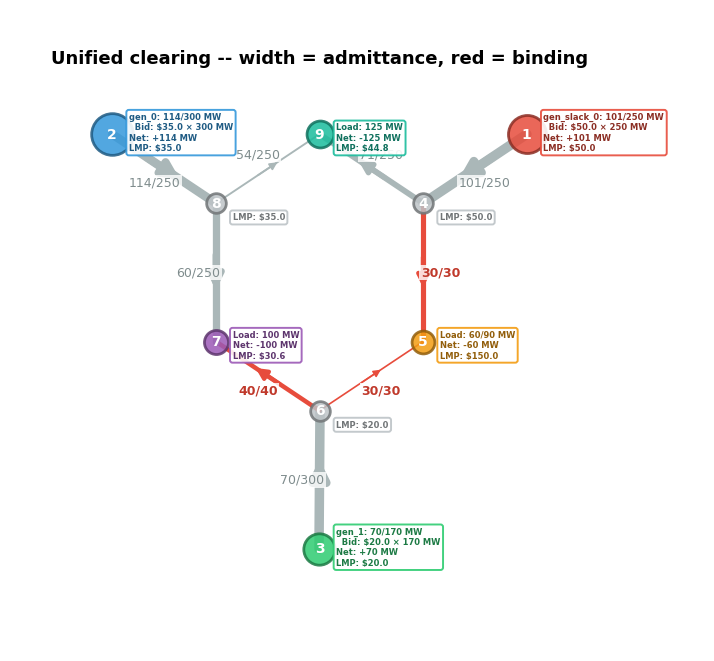

In [7]:
# Topology with DC power flow. Line WIDTH = susceptance (b=1/x); line COLOUR =
# congestion. A line is red only when its shadow price is non-zero (a genuine
# binding transmission limit) -- NOT merely when flow hits rating, which can
# happen because the generator behind a radial line is maxed out.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
flows = {l: res.flow_own[l] for l in pt.lines}
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=res.lmp, line_flows=flows,
    bus_net_mw={b: float(res.injection[pt.bus_idx[b]]) for b in pt.buses},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines, bus_coords=COORDS,
    demand_served_by_bus=served_by_bus(res, dem),   # 'served/total' where load is shed
    title='Unified clearing -- width = admittance, red = binding',
)
plt.show()

### The nodal dispatch diagram, and the congestion shadow price

The **nodal dispatch diagram** (a circlize / chord chart), built here from the unified DC-OPF. Each sector is a bus. The bar's height for a generator is that unit's marginal cost (its bid) -- solid
where dispatched, faded where it is available capacity. A **dashed line is drawn across each
bus at its cleared LMP**; the gap between a dispatched bar's top and that line is the unit's
**inframarginal rent** (LMP - marginal cost), while a bar rising *above* the line is out of
merit at this price and stays undispatched. The bar's height for a demand bus is drawn at LMP height, and the
**chords** are PTDF-traced generator→load deliveries. Below the figure we print the
congestion shadow price $\mu_m$ on each binding line — the dual of the binding-line
limit, and the exact quantity that splits the LMPs through $\sum_m SF_{n,m}\,\mu_m$.

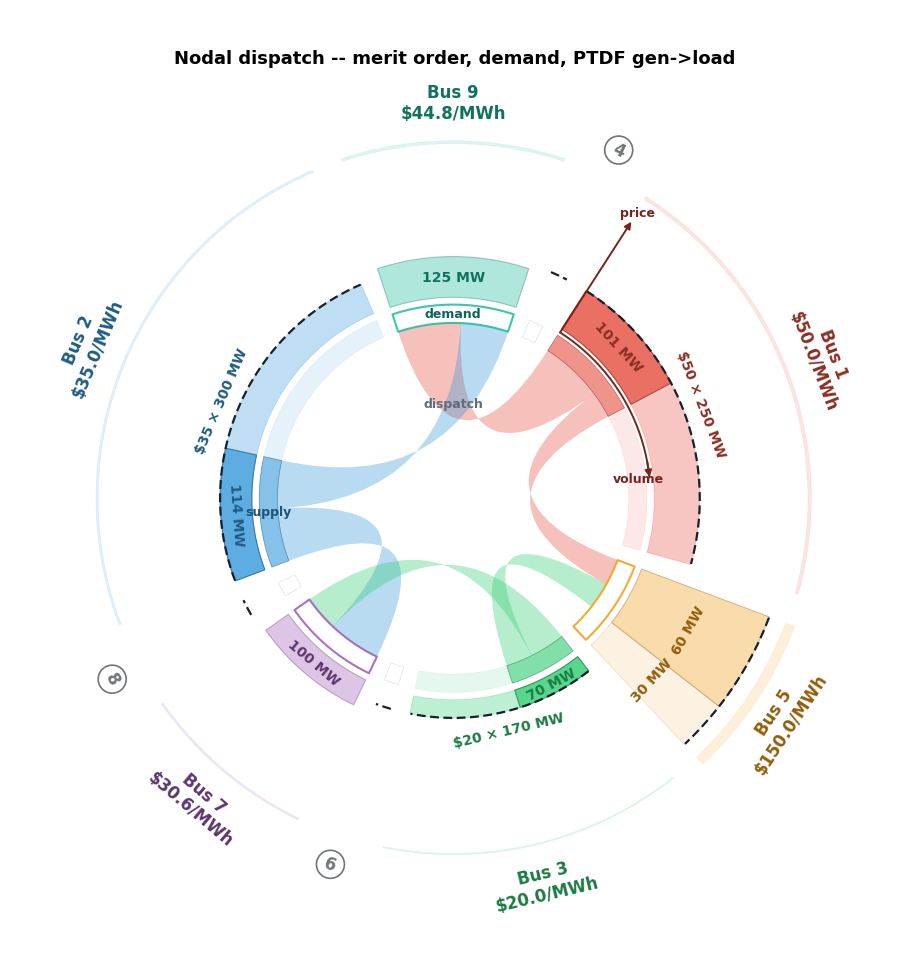

Binding transmission constraints -- congestion shadow price |mu_m|:

  line_2 (5-6): |mu| = $140.37/MWh   (flow -30 MW at the 30 MW limit)

  line_1 (4-5): |mu| = $94.39/MWh   (flow +30 MW at the 30 MW limit)

  line_4 (6-7): |mu| = $4.46/MWh   (flow +40 MW at the 40 MW limit)


Settlement by node  (payments to generation vs payments by load):

...

Revenue adequacy is preserved by reducing the load SERVED, not by relaxing a line or serving unpaid load: shed load pays nothing, so paid-by-load - paid-to-gen still equals the line congestion rent exactly. The shed penalty (SHED_PRICE x MW) is an objective-function term -- the value of lost load -- not a settlement cash flow.


Marginal value of line capacity  (shadow price x flow, per line):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,101.1,250.0,False,0.0,0.0
line_1,4,5,30.0,30.0,True,94.39,2831.7
line_2,5,6,-30.0,30.0,True,140.37,4211.0
line_3,3,6,70.0,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,4.46,178.5
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-113.9,250.0,False,0.0,0.0
line_7,8,9,53.9,250.0,False,0.0,0.0
line_8,9,4,-71.1,250.0,False,0.0,0.0


The |mu| column is the value of relaxing each line by 1 MW; only binding lines carry a positive value.
The rent column decomposes the congestion rent above by line and totals $7,221.2/h.


wrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  C:\Users\docke\Projects\wscc9-illustrative-models

In [8]:
# Nodal dispatch diagram (circlize / chord) of the unified clearing (reuses sup, dem, colors, res from above).
flow_list = nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem))   # PTDF-traced gen->load chords (on SERVED load)

fig = plot_nodal_circlize(
    sup, dem, pt.buses,
    flows=flow_list,
    clearing_price=res.energy_price,
    bus_lmps=res.lmp,
    bus_colors=colors,
    demand_segments=shed_segments(res, dem),   # faint tail (bus colour) = shed (unserved) load
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost (gap = inframarginal rent)
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    sector_order=RING_ORDER,   # clockwise from 12 o'clock, following the network ring
    center_bus=CENTER_BUS,     # bus 9 centred at 12 o'clock (matches the rotated node diagram)
    figsize=(8.5, 9.0),        # fills the width of an 8.5x11 page (extra height -> title headroom)
    label_fontsize=12,         # outer sector labels (Bus N / LMP)
    track_fontsize=10,         # in-track bid / dispatch / load-MW labels, >= 10 pt
    show_legend=False,         # per-bus gen/load/LMP already on the ring + in-track; legend was sub-10 pt and duplicative
    title='Nodal dispatch -- merit order, demand, PTDF gen->load',
)
plt.show()

# Shadow price of the binding line constraint(s): the congestion dual mu_m.
binding = {l: mu for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
if binding:
    print('Binding transmission constraints -- congestion shadow price |mu_m|:')
    for l, mu in sorted(binding.items(), key=lambda kv: -abs(kv[1])):
        i = pt.line_idx[l]; a, b = pt.line_buses[i]
        print(f'  {l} ({a}-{b}): |mu| = ${abs(mu):.2f}/MWh   '
              f'(flow {res.flow_own[l]:+.0f} MW at the {pt.s_nom[i]:.0f} MW limit)')
else:
    print('No binding line constraints -- every bus collapses to the single energy price.')

# ── Settlement accounting: payments by node, subtotals, congestion rent ──────
# Convention: "paid to gen" is cash IN to generators (LMP x dispatch); "paid by
# load" is cash OUT from loads (LMP x demand). The system operator collects the
# difference as congestion rent / merchandising surplus -- and that residual
# equals the shadow-price money  sum_m |mu_m| * F_m  (the price-difference rent).
settle = pd.DataFrame(
    [{'bus': b,
      'LMP ($/MWh)': round(res.lmp[b], 2),
      'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
      'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
      'load (MW)': round(unified.loads.get(b, 0.0), 1),
      'served (MW)': round(unified.loads.get(b, 0.0) - res.shed_by_bus.get(b, 0.0), 1),
      'paid by load ($/h)': round(res.lmp[b] * (unified.loads.get(b, 0.0)
                                                - res.shed_by_bus.get(b, 0.0)), 1)}
     for b in pt.buses]
).set_index('bus')

# Settle on SERVED load: shed (unserved) load consumes nothing and pays nothing.
gen_rev  = settle['paid to gen ($/h)'].sum()    # subtotal: total to generation
load_pay = settle['paid by load ($/h)'].sum()   # subtotal: total from served load
settle.loc['SUBTOTAL'] = ['', settle['gen (MW)'].sum(), gen_rev,
                          settle['load (MW)'].sum(), settle['served (MW)'].sum(), load_pay]

print('\nSettlement by node  (payments to generation vs payments by load):')
display(settle)

cong_rent = load_pay - gen_rev
mu_money  = sum(abs(mu) * abs(res.flow_own[l]) for l, mu in binding.items())
print(f'Congestion rent  =  paid by load  -  paid to gen  '
      f'=  {load_pay:,.1f}  -  {gen_rev:,.1f}  =  ${cong_rent:,.1f}/h')
print(f'Shadow-price check:  sum_m |mu_m| * F_m over binding lines  =  ${mu_money:,.1f}/h')
print('(equal by the LMP decomposition: the energy component nets to zero because '
      'total generation = total SERVED load,\n so only the congestion term survives, and it equals mu x flow on each binding line.)')

# Load shedding (power-balance relaxation): if any load is unserved, settlement
# is on SERVED load, so the rent identity above still balances -- revenue
# adequacy holds with NO relaxed line limits and NO unpaid phantom load.
_shed_total = sum(res.shed_by_bus.values())
if _shed_total > 1e-6:
    _where = ', '.join(f'bus {b} {u:.0f} MW' for b, u in res.shed_by_bus.items())
    print(f'\nLoad shed: {_shed_total:.0f} MW unserved ({_where}), each shed bus priced at '
          f'SHED_PRICE = ${SHED_PRICE:.0f}/MWh (its LMP -- the relaxation penalty is the price cap).')
    print('Revenue adequacy is preserved by reducing the load SERVED, not by relaxing a line or '
          'serving unpaid load: shed load pays nothing, so paid-by-load - paid-to-gen still equals '
          'the line congestion rent exactly. The shed penalty (SHED_PRICE x MW) is an '
          'objective-function term -- the value of lost load -- not a settlement cash flow.')

# ── Marginal value of line capacity: shadow price x flow, per line ───────────
# |mu_m| is the $/MWh fall in system cost from +1 MW of rating on line m (zero
# unless the line binds) -- the marginal value of capacity. |mu_m| x flow is the
# congestion rent that line collects; the column sums to the total rent above.
lines_tbl = pd.DataFrame(
    [{'line': l,
      'from': pt.line_buses[pt.line_idx[l]][0],
      'to': pt.line_buses[pt.line_idx[l]][1],
      'flow (MW)': round(res.flow_own[l], 1),
      'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
      'binding': abs(res.line_dual[l]) > 1e-3,
      '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
      'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
     for l in pt.lines]
).set_index('line')
lines_tbl.loc['TOTAL'] = ['', '', '', '', '', '',
                          round(lines_tbl['rent |mu| x flow ($/h)'].sum(), 1)]

print('\nMarginal value of line capacity  (shadow price x flow, per line):')
display(lines_tbl)
print('The |mu| column is the value of relaxing each line by 1 MW; only binding '
      'lines carry a positive value.\nThe rent column decomposes the congestion '
      f'rent above by line and totals ${lines_tbl.loc["TOTAL", "rent |mu| x flow ($/h)"]:,.1f}/h.')

# ── Export both tables to CSV (overwritten every run) for the Word write-up ──
settle.to_csv('seams_settlement_by_node.csv')
lines_tbl.to_csv('seams_line_capacity_value.csv')
print(f'\nwrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  {os.getcwd()}')

### Composite figure 

The network diagram and the nodal dispatch diagram laid out side by side,
sized so the fonts stay clean at half-page width:

- node numbers sit in small chips **beside** each bubble (the coloured marker stays
  uncluttered); only the **LMP** is printed at each bus — the gen/bid/load detail
  lives in the nodal dispatch panel, so nothing is duplicated;
- on each bus sector the **bid** sits *outside / on top of* the gen bar and the
  **dispatched MW** sits *inside* it (mirroring the load bar, which prints its MW
  in-track); in-track labels are placed by bar height so they stay inside the bar;
- saved as a PNG and a vector PDF, overwritten each run.

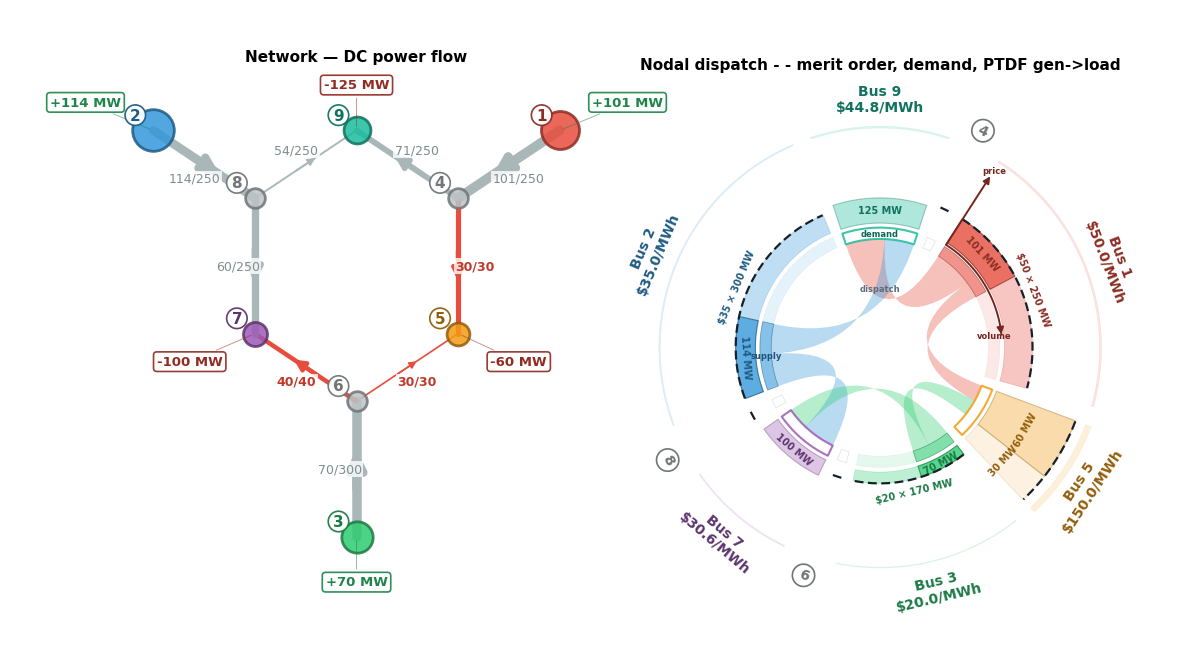

wrote cra_combined_figure.png (600 dpi) and cra_combined_figure.pdf to C:\Users\docke\Projects\wscc9-illustrative-models

In [9]:
from nodal_plot import plot_combined_letter

binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    bus_net_mw={b: float(res.injection[pt.bus_idx[b]]) for b in pt.buses},
    network_show_lmp=False,   # network panel shows net injection/withdrawal; price is on the ring
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem)),
    clearing_price=res.energy_price,
    demand_segments=shed_segments(res, dem),   # faint tail (bus colour) = shed (unserved) load
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,   # rotated node diagram + bus 9 at 12 o'clock
    title_right='Nodal dispatch - - merit order, demand, PTDF gen->load',
)
fig.savefig('cra_combined_figure.png', dpi=600, bbox_inches='tight')
fig.savefig('cra_combined_figure.pdf', bbox_inches='tight')   # vector, for Word
plt.show()
print(f'wrote cra_combined_figure.png (600 dpi) and cra_combined_figure.pdf to {os.getcwd()}')

**Read it:** with `line_4` (6–7) limited to 40 MW, the binding internal limit
splits the LMPs — the bus-7 load behind the constraint prices up to ~\$37 while the
cheap bus-3 pocket (\$20) stays low. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$; set `LINE_RATINGS = {}` and re-run to collapse every bus
back to a single energy price.

## 3. Transport constraints and transfer rent

Nodal pricing constrains individual *lines*. Markets also limit **transport
between areas**: group the buses into two regions and hold the **net interchange**
$E$ (region A's net export, equal to the summed flow across the interface) within
a scheduling limit $\bar E$:

$$-\bar E \;\le\; E \;\le\; \bar E \qquad [\,\mu_T\,].$$

When the limit binds it carries a shadow price $\mu_T$; every bus in region A
picks up the same $+\mu_T$ term, so the two regions' energy prices separate by
$\mu_T$. The **transfer rent** is

$$R_T \;=\; |\,\mu_T \cdot E\,| ,$$

the transport analogue of line congestion rent. (`revenue_allocation.solve_with_transfer`
adds the constraint; `transfer_rent` reads $R_T$ off the dual.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Region A net export: unconstrained +215 MW  ->  capped at 150 MW

transfer shadow price |mu_T| = $15.00/MWh   (prices separate by this between the regions)

transfer rent  R_T = |mu_T * E| = $2,250.0/h

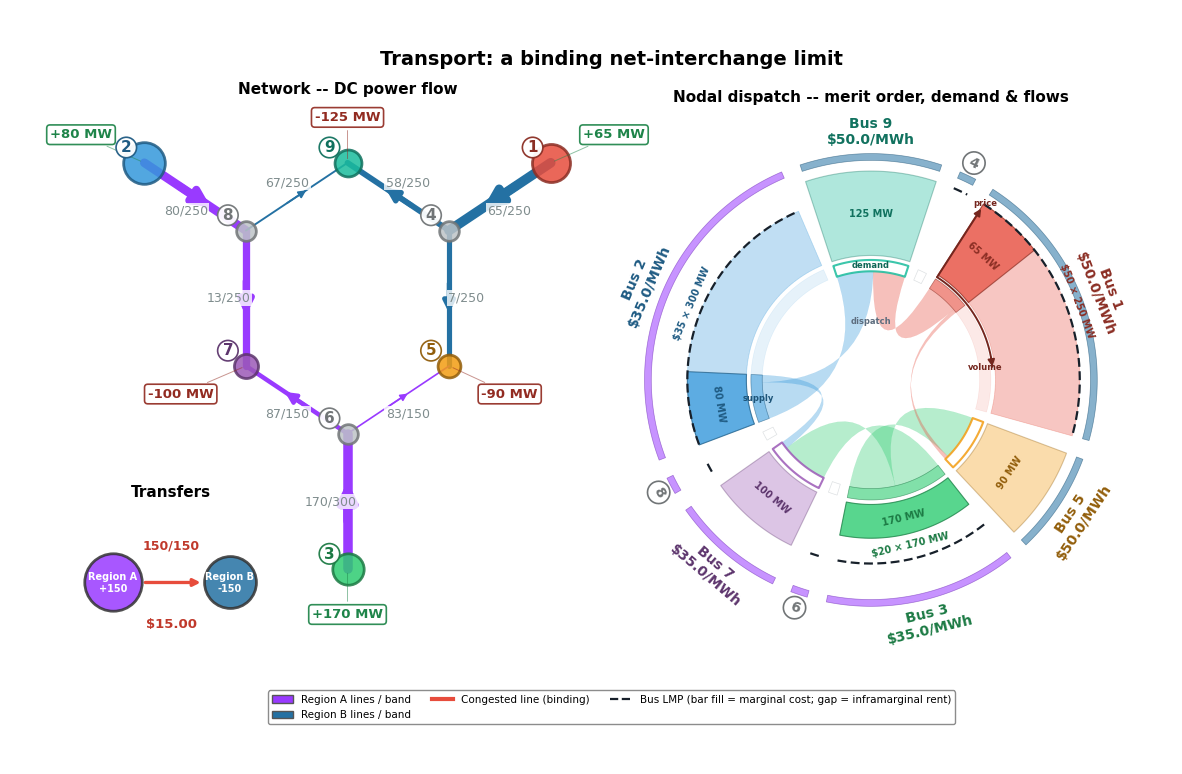

In [10]:
# Two regions on the same network; cap the net interchange between them.
REGIONS = {'Region A': ['2', '8', '7', '6', '3'], 'Region B': ['1', '9', '4', '5']}
REGION_COLORS = {'Region A': '#993AFF', 'Region B': '#2471A3'}
REGION_LINES  = {'Region A': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],
                 'Region B': ['line_0', 'line_1', 'line_7', 'line_8']}
ptU = shift_factors()
fp  = fpmod.make(ptU, REGIONS, REGION_COLORS, manage=REGION_LINES, tie_label='tie')
TIE_CAP = float(sum(ptU.s_nom[ptU.line_idx[l]] for l in fp.ties))   # combined interface rating

# Clear once with a slack limit to read the natural interchange, then cap below it.
_, _, _, r0 = ra.solve_with_transfer(fp, {}, TIE_CAP)
E0 = r0.interchange_mw
TRANSFER_LIMIT = round(abs(E0) * 0.7 / 5) * 5                       # tighten so the schedule binds
n_t, p_t, e_t, r_t = ra.solve_with_transfer(fp, {}, TRANSFER_LIMIT)
print(f'Region A net export: unconstrained {E0:+.0f} MW  ->  capped at {TRANSFER_LIMIT:.0f} MW')
print(f'transfer shadow price |mu_T| = ${abs(r_t.interchange_dual):.2f}/MWh   '
      f'(prices separate by this between the regions)')
print(f'transfer rent  R_T = |mu_T * E| = ${ra.transfer_rent(r_t):,.1f}/h')
figs.transfer_figure(n_t, p_t, fp, e_t, r_t, TRANSFER_LIMIT, TIE_CAP, node_net_mw=True,
                     suptitle='Transport: a binding net-interchange limit')
plt.show()

## 4. Self-schedules

A **self-schedule** is a fixed, price-taking injection $\mathrm{exo}_n$ the clear
must absorb — a quantity, with no bid price. It shifts a region's residual supply
curve and moves the LMPs without *setting* one. Below, an 80 MW self-schedule
delivered into bus 9 (a load bus in the expensive region) displaces local supply
and pulls its LMP toward the cheaper region's price. (`solve_engine_dispatch(exo=…)`
carries it; `+` = injection into the footprint.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


self-schedule: 80 MW delivered into bus 9

,1,2,3,4,5,6,7,8,9
LMP base ($/MWh),35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0
LMP w/ self-sched ($/MWh),35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0


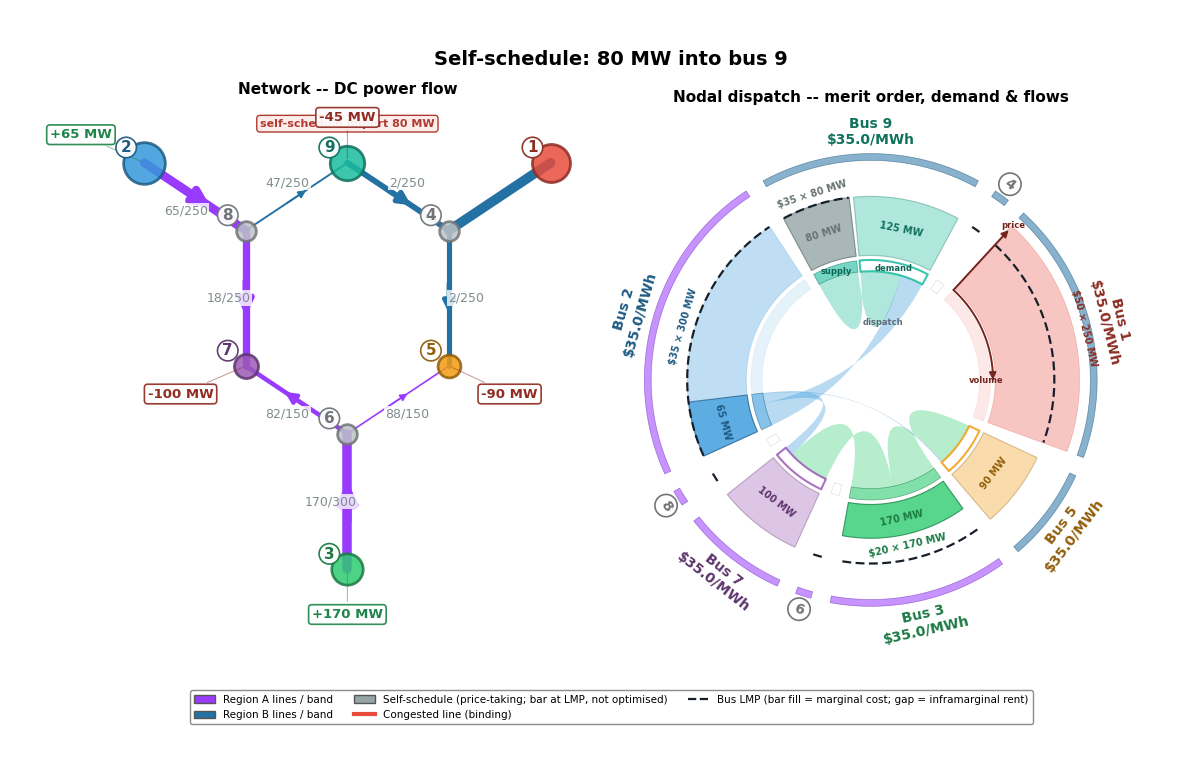

In [11]:
SELF_BUS, SELF_MW = '9', 80.0
n_s = build_network(); p_s = compute_ptdf(n_s, slack_bus='1')
eng_s = make_engine('UNIFIED', buses=p_s.buses)
r_base = solve_engine_dispatch(p_s, eng_s)
r_self = solve_engine_dispatch(p_s, eng_s, exo={SELF_BUS: SELF_MW})

cmp = pd.DataFrame({
    'LMP base ($/MWh)':       {b: round(r_base.lmp[b], 2) for b in p_s.buses},
    'LMP w/ self-sched ($/MWh)': {b: round(r_self.lmp[b], 2) for b in p_s.buses},
}).T
print(f'self-schedule: {SELF_MW:.0f} MW delivered into bus {SELF_BUS}')
display(cmp)
figs.footprint_figure(n_s, p_s, fp, eng_s, r_self, exo_sched={SELF_BUS: SELF_MW},
                      node_net_mw=True,
                      suptitle=f'Self-schedule: {SELF_MW:.0f} MW into bus {SELF_BUS}')
plt.show()

## 5. Three settlement ledgers

Every later notebook settles with one of three ledgers. All three close exactly —
positions sum to $-(\text{production cost})$, and any pure transfer price nets out at
the system total.

1. **Congestion-revenue ledger** — each region's consumers and generators at nodal
   LMPs. The congestion rent $R$ is the gap between what *all* load pays and what *all*
   generation is paid; it is money the **system** holds, and it lands in the TOTAL
   column. The next cell **derives the congestion revenue _by region_** and the cell
   after tabulates it, so the per-region piece that genuinely sums to $R$ is kept
   separate from the net settlement position $L_a-G_a$, which is dominated by
   inter-region energy trade. **How the pooled rent is then allocated between the
   balancing authorities is a policy choice**, not a fact of the dispatch; this
   fundamentals notebook does not pick a rule (the 201 notebook is devoted to it).
2. **Transfer-revenue ledger** — the same layout for the transport-constrained clear:
   the transfer rent $R_T=|\mu_T\,E|$, collected at the interface, joins the TOTAL.
3. **Position ledger** — per-region net positions (consumers, generator surplus, a
   trader/self-schedule row) — the form the seams and two-settlement notebooks use.

### The congestion-revenue ledger — two views of the system rent

The first of the three ledgers. Take the unified clearing with `line_4` (6–7) capped at
40 MW — the single-constraint case this section uses throughout — and read the congestion
rent $R$ two equal ways. **Settlement by node** lists what every bus's load pays and every
bus's generation is paid at the nodal LMPs; the `Total − congestion rent` row is *paid by
load* minus *paid to gen*, the residual the system holds. **Marginal value of line capacity**
prices each line at $|\mu_m|\times$ flow; the `TOTAL` row sums to the same $R$, and the
`binding` column flags the line that actually constrains. The next subsection then splits that
pooled $R$ across the balancing authorities.

In [12]:
# (1) Congestion-revenue ledger -- the pooled system rent R, two equal ways.  Same clearing the
# rest of Section 5 uses: line_4 (6-7) capped at 40 MW (a single binding constraint, so the
# per-region split below stays clean).  settlement_by_bus and capacity_value_by_line are the
# shared helpers every later notebook settles with.
from revenue_allocation import settlement_by_bus, capacity_value_by_line
rat_c = {'line_4': 40.0}
n_c = build_network(rat_c); p_c = compute_ptdf(n_c, slack_bus='1')
r_c = solve_engine_dispatch(p_c, make_engine('UNIFIED', buses=p_c.buses), shed_price=150.0)

node_ledger = settlement_by_bus(r_c, p_c.buses, LOADS)
_lp = node_ledger.loc['SUBTOTAL', 'paid by load ($/h)']
_gp = node_ledger.loc['SUBTOTAL', 'paid to gen ($/h)']
node_ledger.loc['Total - congestion rent'] = ['', '', '', '', round(_lp - _gp, 1)]
print('Settlement by node (unified clearing, line_4 capped at 40 MW):')
display(node_ledger)
print('Marginal value of line capacity -- shadow price x flow (TOTAL = congestion rent):')
display(capacity_value_by_line(r_c, p_c, p_c.lines))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Settlement by node (unified clearing, line_4 capped at 40 MW):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,27.74,0.0,0.0,0.0,0.0
2,35.0,176.1,6162.4,0.0,0.0
3,20.0,138.9,2778.6,0.0,0.0
4,27.74,0.0,0.0,0.0,0.0
5,25.02,0.0,0.0,90.0,2251.8
6,20.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
8,35.0,0.0,0.0,0.0,0.0
9,30.25,0.0,0.0,125.0,3780.8


Marginal value of line capacity -- shadow price x flow (TOTAL = congestion rent):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,-0.0,250.0,False,0.0,0.0
line_1,4,5,-8.9,250.0,False,0.0,0.0
line_2,5,6,-98.9,150.0,False,0.0,0.0
line_3,3,6,138.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-176.1,250.0,False,0.0,0.0
line_7,8,9,116.1,250.0,False,0.0,0.0
line_8,9,4,-8.9,250.0,False,0.0,0.0


### Deriving the congestion revenue *by region*

Section 2 priced every bus, eq. (5), and collected the system rent, eq. (6); here we
split that rent across the balancing authorities. Start from the nodal price, extended
to carry the net-interchange term of Section 3, and written with the system energy
price $\lambda$ held **separate** from the two binding-constraint terms:

$$\lambda_n \;=\; \underbrace{\lambda}_{\text{energy}}
            \;+\; \underbrace{\sum_{m}SF_{n,m}\,\mu_m}_{\text{line congestion}}
            \;+\; \underbrace{w_n\,\mu_T}_{\text{transfer}},
  \qquad\qquad (7)$$

where $w_n=\mathbf{1}\{n\in A\}$ marks the area whose interchange is capped — so a
region's *effective* energy cost is $\lambda+w_a\mu_T$, and the regions' energy costs
separate exactly when the transfer binds.

**Region $a$'s net settlement position** — what its load pays minus what its generators
are paid:

$$N_a \;=\; L_a - G_a
     \;=\; \sum_{n\in a}\lambda_n d_n - \sum_{n\in a}\lambda_n g_n
     \;=\; \sum_{n\in a}\lambda_n\,(d_n-g_n). \qquad\qquad (8)$$

**Substitute the price (7)** and collect the three terms:

$$N_a \;=\; \underbrace{\lambda\!\sum_{n\in a}(d_n-g_n)}_{=\;\lambda\,e_a}
     \;+\; \underbrace{\sum_{m}\mu_m\!\sum_{n\in a}SF_{n,m}(d_n-g_n)}_{=\;N_a^{c}}
     \;+\; \underbrace{\mu_T\!\sum_{n\in a}w_n(d_n-g_n)}_{=\;N_a^{T}}. \qquad (9)$$

The first term is the **energy** of the region's net trade, with
$e_a=\sum_{n\in a}(d_n-g_n)$ its net import; the second is **line congestion**; the
third is **transfer scarcity**. Rearranging (8)–(9), the load bill reads

$$\boxed{\,L_a \;=\; \underbrace{G_a + \lambda\,e_a}_{\text{generation payment serving }a}
              \;+\; N_a^{T} \;+\; N_a^{c}\,} \qquad\qquad (10)$$

— load pays for the generation that serves it (its own units at their price $G_a$,
plus its net imports at the common $\lambda$) and, on top, the two scarcity rents.

**The congestion revenue by region — two equal forms.** Write region $a$'s contribution
to the flow on line $m$ as $F_m^a=\sum_{n\in a}SF_{n,m}(g_n-d_n)$. The middle term of (9)
can be read off the prices, or built from the network — the same number:

$$N_a^{c}
  \;=\; \underbrace{\sum_{n\in a}(\lambda_n-\lambda)(d_n-g_n)}_{\text{(a) from the prices}}
  \;=\; \underbrace{-\sum_{m}\mu_m\,F_m^a}_{\text{(b) from the network}}. \qquad\qquad (11)$$

They are equal because the price deviation **is** the shift-factor-weighted shadow price,
$\lambda_n-\lambda=\sum_m SF_{n,m}\mu_m$: form **(a)** nets $\lambda$ out of the published nodal
LMPs; form **(b)** takes the shadow price $\mu_m$ on each binding line times the flow the
region's own injections put on it, $F_m^a$. The companion table below works form (b) bus by
bus — each bus's net injection $g_n-d_n$ times its shift factor is the flow it adds to the
constrained line, and $-\mu_m$ times that is the congestion it **causes** ($+$) or **relieves**
($-$); the region subtotals are $F_m^a$ and $N_a^{c}$. At the transaction level a delivery of
$q$ from generator $s$ to load $k$ pays $q(\lambda_k-\lambda_s)=q\sum_m(SF_{k,m}-SF_{s,m})\mu_m$
— the same $\mu_m$ times the gen-to-load shift factor.

**It partitions the system rent.** Summing (11) over regions, $\sum_a F_m^a=F_m$ (the
whole flow on line $m$), so

$$\sum_a N_a^{c} \;=\; -\sum_m \mu_m F_m \;=\; \sum_m |\mu_m F_m| \;=\; R, \qquad\qquad (12)$$

and likewise $\sum_a N_a^{T}=R_T$, while the energy terms cancel,
$\sum_a \lambda e_a=\lambda\sum_n(d_n-g_n)=0$. So $N_a^{c}$ is exactly the per-region
split of $R$ the dispatch produces — and by (11) it depends on the shadow prices
$\mu_m$ and the shift factors, **not** on $\lambda$, which cancels.

**Why not just $L_a-G_a$?** That is $N_a$, and (9) shows it also carries the energy term
$\lambda e_a$ — which for an importer dwarfs the congestion. Most of its $L_a-G_a$ is the
bill for imported energy that pays *other* regions' generators, so it is a net
settlement position, not congestion revenue.

In [13]:
# (1) Congestion-revenue ledger -- unpack each region's load bill into the generation it
# pays for and the scarcity it bears, with the energy price lambda held SEPARATE from the
# binding constraints:   L_a = G_a + lambda*e_a + N_a^T + N_a^c.
rat_c = {'line_4': 40.0}
n_c = build_network(rat_c); p_c = compute_ptdf(n_c, slack_bus='1')
r_c = solve_engine_dispatch(p_c, make_engine('UNIFIED', buses=p_c.buses), shed_price=150.0)
lam_c = float(r_c.energy_price)

rc = ra.regional_congestion(fp, r_c, p_c, LOADS)
cong = pd.DataFrame({reg: {
    'Load payment  L_a':                                    rc[reg]['load_pay'],
    'Gen revenue WITHIN region  G_a':                       rc[reg]['gen_rev_within'],
    'Net import  e_a  (MW)':                                rc[reg]['net_import'],
    'Imported energy @ lambda  (lambda*e_a)':               rc[reg]['energy_payment'],
    'Generation payment serving region  (G_a + lambda*e_a)': rc[reg]['gen_payment'],
    'Transfer scarcity  N_a^T':                             rc[reg]['transfer'],
    'Congestion revenue by region  N_a^c':                  rc[reg]['line_congestion'],
} for reg in fp.areas})
cong['TOTAL'] = cong.sum(axis=1)
sum_nc = sum(rc[reg]['line_congestion'] for reg in fp.names)
sum_nt = sum(rc[reg]['transfer'] for reg in fp.names)
print(f'energy price  lambda = ${lam_c:,.1f}/MWh  -- the single reference; a region effective price = lambda + w_a*mu_T')
print(f'identity per region:   L_a  =  (G_a + lambda*e_a)  +  N_a^T  +  N_a^c')
print(f'congestion revenue by region N_a^c sums to R = ${sum_nc:,.0f}   |   transfer N_a^T sums to R_T = ${sum_nt:,.0f}')
display(cong.round(1))

# Second table -- the shift-factor build-up of the congestion-revenue-by-region (eq 11,
# network form): each bus's net injection x its shift factor = the flow it adds to the binding
# line; times -mu that is the congestion it causes (+) or relieves (-).  Sums to N_a^c by region.
print()
print("shift-factor build-up of  N_a^c  (eq 11, form b: congestion = causer(+)/reliever(-)):")
display(ra.congestion_shift_breakdown(fp, r_c, p_c, LOADS).round(2))

# Aside -- would charging every load the single system lambda fund generation?  No.
D_tot = sum(LOADS.values()); G_tot = sum(r_c.lmp[b] * r_c.gen_by_bus.get(b, 0.0) for b in p_c.buses)
print(f'aside -- charge ALL load the system lambda:  lambda*D = ${lam_c*D_tot:,.0f}   vs   '
      f'generators owed at their LMP = ${G_tot:,.0f}')
print(f'  -> short by ${G_tot - lam_c*D_tot:,.0f} (the generator-side congestion): a flat energy charge does NOT')
print(f'     fund nodal generation -- the load bill has to carry the congestion, not just the energy.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


energy price  lambda = $27.7/MWh  -- the single reference; a region effective price = lambda + w_a*mu_T

identity per region:   L_a  =  (G_a + lambda*e_a)  +  N_a^T  +  N_a^c

congestion revenue by region N_a^c sums to R = $804   |   transfer N_a^T sums to R_T = $0

,Region A,Region B,TOTAL
Load payment L_a,3712.6,6032.5,9745.1
Gen revenue WITHIN region G_a,8941.0,0.0,8941.0
Net import e_a (MW),-215.0,215.0,-0.0
Imported energy @ lambda (lambda*e_a),-5963.3,5963.3,-0.0
Generation payment serving region (G_a + lambda*e_a),2977.7,5963.3,8941.0
Transfer scarcity N_a^T,0.0,0.0,0.0
Congestion revenue by region N_a^c,734.9,69.2,804.1


shift-factor build-up of  N_a^c  (eq 11, form b: congestion = causer(+)/reliever(-)):

,region,net inj g-d (MW),SF to line_4,flow on line_4 (MW),congestion N_a^c ($/h)
bus,,,,,
2,Region A,176.07,-0.36134,-63.62,-1278.93
7,Region A,-100.00,-0.467098,46.71,938.98
3,Region A,138.93,0.384841,53.47,1074.80
Region A total,,215.00,,36.56,734.85
9,Region B,-125.00,-0.124853,15.61,313.73
5,Region B,-90.00,0.135135,-12.16,-244.49
Region B total,,-215.00,,3.44,69.24


aside -- charge ALL load the system lambda:  lambda*D = $8,737   vs   generators owed at their LMP = $8,941

  -> short by $204 (the generator-side congestion): a flat energy charge does NOT

     fund nodal generation -- the load bill has to carry the congestion, not just the energy.

### Do both regions gain vs going it alone? (autarky Pareto test)

A natural fairness check: is each region at least as well off under the unified clearing as
**going it alone**? For "going it alone" we use the **accommodation** baseline. The region that
owns the constrained line — **Region A owns `line_4` (6–7)** — cannot simply ignore the
neighbour: when Region B schedules independently, its dispatch pushes loop flow onto `line_4`,
and Region A still has to keep that line within its 40 MW limit. So Region A's baseline clears
with **Region B's autarky injections held exogenous**, bearing the loop flow (and the congestion
rent and redispatch that come with it); Region B self-serves. This is a stricter — and more
honest — "alone" than a clean island, and the ledger labels it *Autarky Accommodation*.

The check needs the pooled congestion rent rebated *somehow*, and that is exactly the policy
choice above. Here we use the simplest neutral default — **rebate the rent to load pro-rata by
load share**, a uniform consumer uplift. Treat this as one *general uplift methodology*; the 201
notebook explores allocation rules (and their distributional consequences) in depth. Watch
Region A: because accommodation autarky lets it keep the congestion rent on its own line, a flat
pro-rata rebate can leave its consumers *worse* off under pooling — a live distributional signal,
not a bug.

In [14]:
# Pro-rata-by-load uplift of the total congestion rent (a general uplift rule), then the
# autarky/Pareto ledger with the congestion-revenue derivation folded into the Unified block:
#   R (system)  ->  N_a^c (congestion by region)  ->  allocated (by region)  ->  positions.
# Baseline = ACCOMMODATION autarky: Region A (owns the binding line_4, 6-7) clears with the
# neighbour's autarky injections held EXOGENOUS, so it carries the loop flow they push onto
# line_4 -- and the congestion rent + redispatch that come with it; Region B self-serves.
_, _ind = ra.independent_clear(fp, rat_c, loads=LOADS, shed_price=150.0)
HOST, NBR = 'Region A', 'Region B'            # Region A hosts the binding line_4 (6-7)
_exo = {b: _ind[NBR].gen_by_bus.get(b, 0.0) - LOADS.get(b, 0.0) for b in fp.areas[NBR]}
_act = [l for l in p_c.lines if fp.line_assign.get(l) == HOST]
_rh = solve_engine_dispatch(p_c, make_engine(HOST, fp.areas[HOST], activated=_act),
                            exo=_exo, shed_price=150.0)
accom = {HOST: _rh, NBR: _ind[NBR]}           # accommodation baseline: {area: EngineResult}
relabel_accom = lambda t: t.rename(index=lambda s: s.replace('Autarky', 'Autarky Accommodation')
                                   if isinstance(s, str) else s)

_R = sum(ra.ba_settlement(fp, r_c, LOADS)[reg]['net_into_pool'] for reg in fp.names)
_load = {reg: sum(LOADS.get(b, 0.0) for b in fp.defs[reg]) for reg in fp.names}
prorata = pd.DataFrame({'method1': {reg: _R * _load[reg] / sum(_load.values()) for reg in fp.names}})
print('congestion rent rebated to load pro-rata by load share:',
      {reg: round(prorata.loc[reg, 'method1'], 1) for reg in fp.names})
print('baseline: Region A accommodates Region B exogenous injections (bears the loop flow on its')
print('own line_4); the Unified block walks R (system) -> N_a^c (by region) -> allocation ->')
print('each region consumer/generator Final position, tested against that accommodation autarky.')
display(relabel_accom(ra.autarky_vs_unified_congestion(fp, 1, prorata, accom, r_c, p_c, loads=LOADS)))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


congestion rent rebated to load pro-rata by load share:

{'Region A': np.float64(255.3), 'Region B': np.float64(548.8)}

baseline: Region A accommodates Region B exogenous injections (bears the loop flow on its

own line_4); the Unified block walks R (system) -> N_a^c (by region) -> allocation ->

each region consumer/generator Final position, tested against that accommodation autarky.

Region A           Region B              TOTAL
                                                 Consumer Generator Consumer Generator         
Autarky Accommodation: payment / revenue          -3712.6    2977.7 -10750.0   10750.0   -734.9
Autarky Accommodation: production cost                      -2977.7           -10750.0 -13727.7
Autarky Accommodation: own congestion rent (CRR)    734.9                0.0              734.9
Autarky Accommodation: position                   -2977.7       0.0 -10750.0       0.0 -13727.7
Unified: payment / revenue                        -3712.6    8941.0  -6032.5       0.0   -804.1
Unified: production cost                                    -8941.0               -0.0  -8941.0
Unified: congestion rent -- system (R)                                                    804.1
Unified: congestion by region (N_a^c)               734.9               69.2              804.1
Unified: Congestion Revenue Allocation              255.3              548.8              804.1
Final position                                    -3457.3       0.0  -5483.7       0.0  -8941.0
Delta vs autarky                                   -479.6       0.0   5266.3       0.0   4786.7
Pareto (Delta >= 0)                                    no       yes      yes       yes

In [15]:
# (2) Transfer-revenue ledger -- the SAME decomposition (eqs 7-12) on the transport-
# constrained clear from S3.  Now no line binds, so the line column N_a^c is empty; the
# scarcity shows up in the TRANSFER column N_a^T -- the price separation the net-interchange
# limit creates, collected at the interface as R_T = |mu_T*E|.  Lambda is still held separate:
# each area's effective energy cost is lambda + w_a*mu_T, so the capped area's price drops below
# the reference lambda.   L_a = G_a + lambda*e_a + N_a^T + N_a^c  holds row by row.
lam_t = float(r_t.energy_price); muT = float(r_t.interchange_dual or 0.0)
rt = ra.regional_congestion(fp, r_t, p_t, LOADS)
xfer = pd.DataFrame({reg: {
    'Load payment  L_a':                                     rt[reg]['load_pay'],
    'Gen revenue WITHIN region  G_a':                        rt[reg]['gen_rev_within'],
    'Net import  e_a  (MW)':                                 rt[reg]['net_import'],
    'Imported energy @ lambda  (lambda*e_a)':                rt[reg]['energy_payment'],
    'Generation payment serving region  (G_a + lambda*e_a)': rt[reg]['gen_payment'],
    'Transfer scarcity  N_a^T':                              rt[reg]['transfer'],
    'Congestion revenue by region  N_a^c':                   rt[reg]['line_congestion'],
} for reg in fp.areas})
xfer['TOTAL'] = xfer.sum(axis=1)
R_t_cong = sum(rt[reg]['line_congestion'] for reg in fp.names)
R_t_xfer = sum(rt[reg]['transfer'] for reg in fp.names)
print(f"energy price  lambda = ${lam_t:,.1f}/MWh (the reference);  capped area effective price = lambda + mu_T = ${lam_t+muT:,.1f}")
print(f"total rent = ${R_t_cong + R_t_xfer:,.0f}/h  =  line congestion R ${R_t_cong:,.0f}  +  transfer R_T ${R_t_xfer:,.0f}  (|mu_T*E|, at the interface)")
print(f"the transfer scarcity is an INTERFACE rent (it belongs to the schedule, not either area's wires);")
print(f"the price normalization puts mu_T on the capped area, so it shows in {fp.names[0]}'s column -- but like R,")
print(f"how R_T is split between the areas is a policy choice (the 201 notebook's transfer methods).")
display(xfer.round(1))

energy price  lambda = $50.0/MWh (the reference);  capped area effective price = lambda + mu_T = $35.0

total rent = $2,250/h  =  line congestion R $0  +  transfer R_T $2,250  (|mu_T*E|, at the interface)

the transfer scarcity is an INTERFACE rent (it belongs to the schedule, not either area's wires);

the price normalization puts mu_T on the capped area, so it shows in Region A's column -- but like R,

how R_T is split between the areas is a policy choice (the 201 notebook's transfer methods).

,Region A,Region B,TOTAL
Load payment L_a,3500.0,10750.0,14250.0
Gen revenue WITHIN region G_a,8750.0,3250.0,12000.0
Net import e_a (MW),-150.0,150.0,0.0
Imported energy @ lambda (lambda*e_a),-7500.0,7500.0,0.0
Generation payment serving region (G_a + lambda*e_a),1250.0,10750.0,12000.0
Transfer scarcity N_a^T,2250.0,0.0,2250.0
Congestion revenue by region N_a^c,-0.0,-0.0,0.0


In [16]:
# (3) Position ledger — per-region net positions at the unconstrained clear,
# with a worked self-schedule leg (a pure transfer that cancels at the system total).
n_u = build_network(); p_u = compute_ptdf(n_u, slack_bus='1')
r_u = solve_engine_dispatch(p_u, make_engine('UNIFIED', buses=p_u.buses))
pl = ra.position_ledger(fp, r_u, trader=0.0, trader_label='Self-schedule')
led = pd.DataFrame(pd.Series(pl), columns=['$/h']).round(1)
led.index = pd.MultiIndex.from_tuples(led.index)
display(led)
parties = sum(v for k, v in pl.items() if k[0] != 'Total')
print(f'consumers + generators + self-schedule = ${parties:,.1f}/h  '
      f'(= -(congestion rent + production cost); pure transfers net out)')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


$/h
Region A      consumers       -3500.0
              generators       2550.0
Region B      consumers       -7525.0
              generators          0.0
Self-schedule                     0.0
Total         production cost -8475.0

consumers + generators + self-schedule = $-8,475.0/h  (= -(congestion rent + production cost); pure transfers net out)

## 6. Sandbox

Dial a scenario and watch the revenue flows respond. Toggle line ratings
(congestion), an optional net-interchange cap on region A (transport), and a
self-schedule. Re-run to see the dispatch, the congestion rent $R$, the transfer rent
$R_T$, and the per-region decomposition — the generation payment $G_a+\lambda e_a$, the
line congestion $N_a^c$, and the transfer scarcity $N_a^T$ — move together. No issue is
framed — this is the generic playground the 200- and 300-series notebooks specialise.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


congestion rent  R = $804.1/h    transfer rent  R_T = $0.0/h    load shed: 0 MW

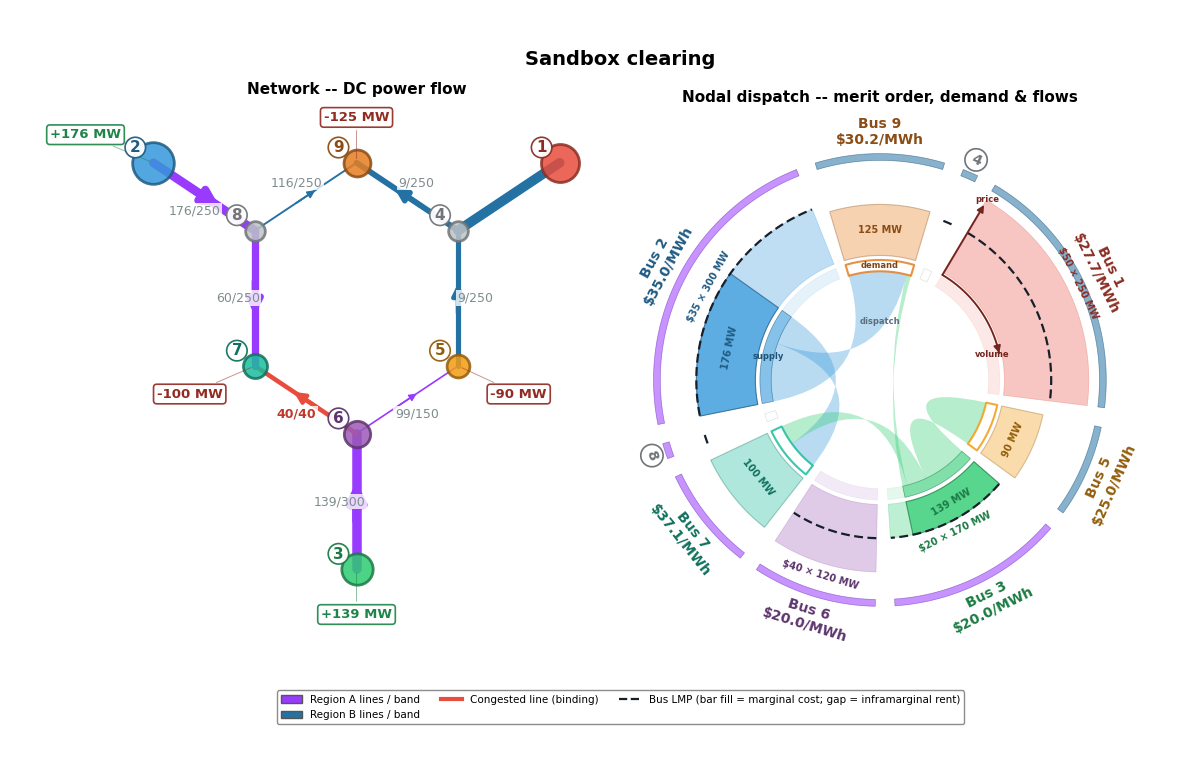

Sandbox -- settlement by node:

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,27.74,0.0,0.0,0.0,0.0
2,35.0,176.1,6162.4,0.0,0.0
3,20.0,138.9,2778.6,0.0,0.0
4,27.74,0.0,0.0,0.0,0.0
5,25.02,0.0,0.0,90.0,2251.8
6,20.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
8,35.0,0.0,0.0,0.0,0.0
9,30.25,0.0,0.0,125.0,3780.8


Sandbox -- marginal value of line capacity (shadow price x flow, TOTAL = congestion rent):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,-0.0,250.0,False,0.0,0.0
line_1,4,5,-8.9,250.0,False,0.0,0.0
line_2,5,6,-98.9,150.0,False,0.0,0.0
line_3,3,6,138.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-176.1,250.0,False,0.0,0.0
line_7,8,9,116.1,250.0,False,0.0,0.0
line_8,9,4,-8.9,250.0,False,0.0,0.0


per-region congestion N_a^c sums to R only when no self-schedule trader is present (a self-schedule carries its own congestion leg -- see the position ledger).

,Region A,Region B,TOTAL
Load payment L_a,3712.6,6032.5,9745.1
Gen revenue WITHIN region G_a,8941.0,0.0,8941.0
Net import e_a (MW),-215.0,215.0,-0.0
Imported energy @ lambda (lambda*e_a),-5963.3,5963.3,-0.0
Generation payment serving region (G_a + lambda*e_a),2977.7,5963.3,8941.0
Transfer scarcity N_a^T,0.0,0.0,0.0
Congestion revenue by region N_a^c,734.9,69.2,804.1


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


autarky/Pareto ledger (congestion rent rebated pro-rata by load):

Region A           Region B              TOTAL
                                       Consumer Generator Consumer Generator         
Autarky: payment / revenue              -3712.6    2908.5 -10750.0   10750.0   -804.1
Autarky: production cost                          -2908.5           -10750.0 -13658.5
Autarky: own congestion rent (CRR)        804.1                0.0              804.1
Autarky: position                       -2908.5       0.0 -10750.0       0.0 -13658.5
Unified: payment / revenue              -3712.6    8941.0  -6032.5       0.0   -804.1
Unified: production cost                          -8941.0               -0.0  -8941.0
Unified: congestion rent -- system (R)                                          804.1
Unified: congestion by region (N_a^c)     734.9               69.2              804.1
Unified: Congestion Revenue Allocation    255.3              548.8              804.1
Final position                          -3457.3       0.0  -5483.7       0.0  -8941.0
Delta vs autarky                         -548.8       0.0   5266.3       0.0   4717.5
Pareto (Delta >= 0)                          no       yes      yes       yes

In [17]:
# -- EDIT -- a full free-form scenario. Every main input is configurable, and a
# bus may gain or lose a generator/load it did not start with.
# Generators -- {bus: (marginal cost $/MWh, capacity MW)}. Add a unit at a
# load-only bus (uncomment bus 5), drop one, or re-cost / re-size any.
SB_GENS = {
    "1": (50.0, 250.0),    # slack, most expensive
    "2": (35.0, 300.0),    # mid-merit
    "3": (20.0, 170.0),    # cheapest
    "6": (40.0, 120.0),  # <- e.g. put a generator where there was only load
}
SB_LOADS = {"5": 90.0, "7": 100.0, "9": 125.0}   # {bus: MW}; add/resize load at any bus
SB_RATINGS  = {"line_4": 40.0}   # line limits (congestion); {} = none
SB_TRANSFER = None               # MW cap on Region A net interchange (None = off)
SB_SELF     = {}                 # {bus: MW} self-schedule (price-taking); {} = none
SHED_PRICE  = 150.0              # load-shed penalty ($/MWh)
# ---------------------------------------------------------------------------
SB_FLEET = {f"gen_{b}": {"bus": b, "cost": c, "p_nom": p} for b, (c, p) in SB_GENS.items()}
n_sb = build_network(SB_RATINGS); p_sb = compute_ptdf(n_sb, slack_bus="1")
eng_sb = make_engine("UNIFIED", buses=p_sb.buses, gen_fleet=SB_FLEET, loads=SB_LOADS)
kw = dict(exo=(SB_SELF or None), shed_price=SHED_PRICE)
if SB_TRANSFER is not None:
    kw["interchange"] = (fp.defs[fp.names[0]], SB_TRANSFER)
r_sb = solve_engine_dispatch(p_sb, eng_sb, **kw)

R  = ra.allocate_congestion_rent(fp, r_sb, p_sb, SB_LOADS)[1]["R"]
RT = ra.transfer_rent(r_sb)
print(f"congestion rent  R = ${R:,.1f}/h    transfer rent  R_T = ${RT:,.1f}/h    "
      f"load shed: {sum(r_sb.shed_by_bus.values()):.0f} MW")

# Colours follow the sandbox fleet so a newly-active bus gets its own colour.
_sbsup = {}
for _g, _s in SB_FLEET.items():
    _sbsup.setdefault(_s["bus"], []).append(_s)
sb_colors = assign_bus_colors(p_sb.buses, _sbsup, SB_LOADS)

figs.footprint_figure(n_sb, p_sb, fp, eng_sb, r_sb, exo_sched=(SB_SELF or None),
                      bus_colors=sb_colors, node_net_mw=True, suptitle="Sandbox clearing")
plt.show()
# Two settlement ledgers for the sandbox clearing -- the SAME pair as Section 5: settlement
# by node (paid by load vs paid to gen; the 'Total - congestion rent' row is the gap) and the
# marginal value of line capacity (|shadow price| x flow, TOTAL = the same congestion rent).
from revenue_allocation import settlement_by_bus, capacity_value_by_line
sb_node = settlement_by_bus(r_sb, p_sb.buses, SB_LOADS)
_lp = sb_node.loc['SUBTOTAL', 'paid by load ($/h)']; _gp = sb_node.loc['SUBTOTAL', 'paid to gen ($/h)']
sb_node.loc['Total - congestion rent'] = ['', '', '', '', round(_lp - _gp, 1)]
print('Sandbox -- settlement by node:')
display(sb_node)
print('Sandbox -- marginal value of line capacity (shadow price x flow, TOTAL = congestion rent):')
display(capacity_value_by_line(r_sb, p_sb, p_sb.lines))

# Per-region decomposition (eqs 7-12):  L_a = G_a + lambda*e_a + N_a^T + N_a^c.
rc_sb = ra.regional_congestion(fp, r_sb, p_sb, SB_LOADS)
sb_tbl = pd.DataFrame({reg: {
    'Load payment  L_a':                                     rc_sb[reg]['load_pay'],
    'Gen revenue WITHIN region  G_a':                        rc_sb[reg]['gen_rev_within'],
    'Net import  e_a  (MW)':                                 rc_sb[reg]['net_import'],
    'Imported energy @ lambda  (lambda*e_a)':                rc_sb[reg]['energy_payment'],
    'Generation payment serving region  (G_a + lambda*e_a)': rc_sb[reg]['gen_payment'],
    'Transfer scarcity  N_a^T':                              rc_sb[reg]['transfer'],
    'Congestion revenue by region  N_a^c':                   rc_sb[reg]['line_congestion'],
} for reg in fp.areas})
sb_tbl['TOTAL'] = sb_tbl.sum(axis=1)
print('per-region congestion N_a^c sums to R only when no self-schedule trader is present '
      '(a self-schedule carries its own congestion leg -- see the position ledger).')
display(sb_tbl.round(1))

# Autarky/Pareto ledger for the sandbox clearing -- the same chain as Section 5: the system
# rent R splits into the congestion each region creates (N_a^c), a pro-rata-by-load uplift
# allocates it, and each region's consumers and generators are tested against autarky.
sb_cost = {s['bus']: s['cost'] for s in SB_FLEET.values()}
_, sb_indep = ra.independent_clear(fp, SB_RATINGS, gen_fleet=SB_FLEET, loads=SB_LOADS, shed_price=SHED_PRICE)
_Rsb = sum(ra.ba_settlement(fp, r_sb, SB_LOADS)[reg]['net_into_pool'] for reg in fp.names)
_loadsb = {reg: sum(SB_LOADS.get(b, 0.0) for b in fp.defs[reg]) for reg in fp.names}
sb_prorata = pd.DataFrame({'method1': {reg: _Rsb * _loadsb[reg] / (sum(_loadsb.values()) or 1.0)
                                       for reg in fp.names}})
print()
print('autarky/Pareto ledger (congestion rent rebated pro-rata by load):')
display(ra.autarky_vs_unified_congestion(fp, 1, sb_prorata, sb_indep, r_sb, p_sb,
                                         loads=SB_LOADS, cost=sb_cost))